# MNIST dataset: collections of 70k images 

- train model on this 70k dataset and the model will predict which image is this
- Model is ANN

- This is multi-class classification. So, in output we only apply those many nodes we have in our class. EG. if 10 output class then 10 nodes at the optput layer, and whichever probability is high that's our output


- Whenever you have more than 1 output nodes (Multi-class classification) use softmax as activation function

# Load and import dataset

In [1]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Flatten

In [2]:
# load the dataset

(X_train,y_train),(X_test,y_test) = keras.datasets.mnist.load_data()

In [ ]:
X_train.shape   # 60k images each with 28*28 layers , 784 layers for 1 image   and 6k images in train data

(60000, 28, 28)

In [ ]:
X_test.shape  # 10k images in test --- 70k total images

(10000, 28, 28)

In [6]:
X_train[0].shape    # the data is the form of "pixels" - 1 image contains 28*28 pixels

(28, 28)

In [7]:
y_train   # labels - which digit is in each label

array([5, 0, 4, ..., 5, 6, 8], shape=(60000,), dtype=uint8)

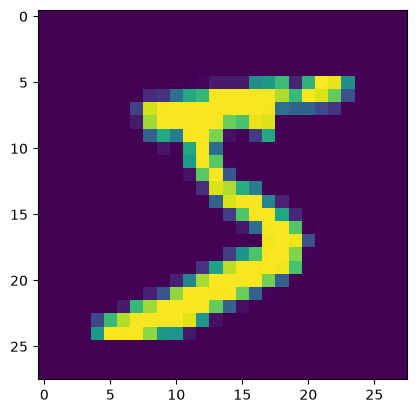

In [10]:
# see which image is present inside each 
import matplotlib.pyplot as plt

plt.imshow(X_train[0])

In [11]:
# in X_train we have values between 0-255 -- so values should be on similar range -- We scale/normalize it
#here we divide by 255, as 255/255=1 and any value less than it will give 0

X_train = X_train / 255

X_test = X_test / 255

In [ ]:
X_train[0]   # now all the values are b/n 0-1 

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

In [22]:
# Train the model - before training we have to flatten it to 1d

model = Sequential()
model.add(Flatten(input_shape=(28,28)))             # each image of size 28*28 is flatten to 784 neurons  - before feeding it into a dense (fully connected) ANN layer .AS Dense layer needs 1d data
model.add(Dense(128,activation='relu'))
model.add(Dense(10,activation='softmax'))  # use when more than 1 output nodes 

c:\Desktop\Desktop\Microsoft_AI_Engineering\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [23]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
model.compile(loss='sparse_categorical_crossentropy', optimizer='Adam', metrics=['accuracy'])  # no need to 1 hot encode when loss is sparse

In [25]:
history = model.fit(X_train, y_train, epochs=10, validation_split=0.2 )   # can increase the epochs for better results

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9191 - loss: 0.2851 - val_accuracy: 0.9542 - val_loss: 0.1602
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9630 - loss: 0.1279 - val_accuracy: 0.9663 - val_loss: 0.1126
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9746 - loss: 0.0869 - val_accuracy: 0.9703 - val_loss: 0.1004
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9806 - loss: 0.0648 - val_accuracy: 0.9698 - val_loss: 0.0967
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9851 - loss: 0.0499 - val_accuracy: 0.9729 - val_loss: 0.0900
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9881 - loss: 0.0382 - val_accuracy: 0.9736 - val_loss: 0.0960
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9910 - loss: 0.0300 - val_accuracy: 0.9745 - val_loss: 0.0851
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9930 - loss: 0.0243 

In [26]:
y_prob = model.predict(X_test)   # this gives probability of each image , which ever is highest probability that's the output(a number)

y_prob

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


array([[5.12340226e-10, 3.24829920e-11, 7.69822293e-07, ...,
        9.99998450e-01, 4.06046219e-08, 1.54676925e-07],
       [2.64649791e-09, 2.48799648e-08, 1.00000000e+00, ...,
        1.26505440e-15, 5.28361521e-10, 9.95681956e-19],
       [3.96151819e-07, 9.99250829e-01, 1.51927030e-04, ...,
        9.97851748e-05, 4.89675382e-04, 1.63180616e-07],
       ...,
       [7.46673450e-19, 4.51259852e-13, 3.85244666e-16, ...,
        9.68883085e-10, 1.39778333e-09, 6.14900060e-08],
       [4.21319236e-14, 1.16663186e-14, 4.46899546e-17, ...,
        1.68932712e-13, 1.09969756e-06, 1.14462854e-17],
       [1.39918100e-07, 8.52495039e-16, 4.88798946e-10, ...,
        1.97411150e-15, 1.05918871e-10, 8.23718958e-12]],
      shape=(10000, 10), dtype=float32)

In [27]:
y_prob.shape  # the ouput shows 10k images each with 10 cols, where it has num from 1-10

(10000, 10)

In [28]:
# Convert probability to actual output of image - whichever prob is max that's the output which model predicted

y_pred = y_prob.argmax(axis=1)   # axis=1 means the operation is peformed "horizontally" across the cols for each row

# this output shows what "model" has predicted on the test data, which num it has predicted based on train data it saw

# at 0th index it says num was 7 , at 1 index num=2 and so on... (this is model's prediction) and this is my "y_pred"

y_pred

array([7, 2, 1, ..., 4, 5, 6], shape=(10000,))

In [29]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)     # actual ans vs predicted ans

0.9749

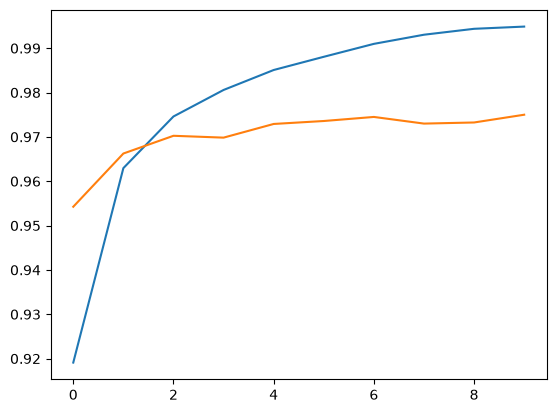

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

# blue is training accuracy -- which says as the epochs increase the accuracy also increase
# orange line is test accuracy - which says as same

# a little Overfit is seen

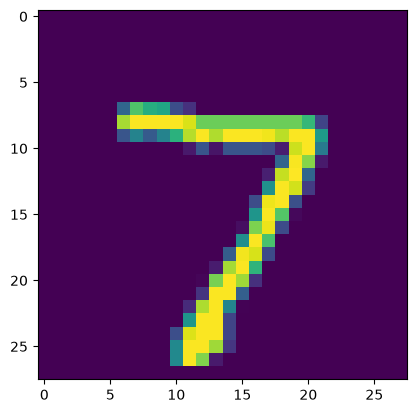

In [ ]:
# verify the predictions

plt.imshow(X_test[0])   # so the first image of test data is 7

In [ ]:
# now model will predict the same image

model.predict(X_test[0].reshape(1,28,28))   # sharing 1 image of 28*28

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 667ms/step


array([[5.1234117e-10, 3.2482992e-11, 7.6982155e-07, 6.0627804e-07,
        7.1646007e-16, 1.6064797e-11, 5.9355431e-15, 9.9999845e-01,
        4.0604700e-08, 1.5467707e-07]], dtype=float32)

In [ ]:
model.predict(X_test[0].reshape(1,28,28)).argmax(axis=1)  # so model predicted correctly

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step


array([7])